<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Selección de Características e Información Mutua (Mutual Information) 🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
### 1. ¿Qué es la Selección de Características (*Feature Selection*)? 🎯

La **Selección de Características (*Feature Selection*)** es el proceso sistemático mediante el cual se reduce la cantidad de variables de un conjunto de datos, empleando criterios estadísticos o de rendimiento para conservar únicamente aquellas variables que resultan verdaderamente útiles para predecir la variable objetivo ($y$) con nuestro modelo.

En problemas reales de Ciencia de Datos es muy habitual trabajar con datasets de alta dimensionalidad. Sin embargo:
* Frecuentemente muchas características resultan **completamente irrelevantes, redundantes o insignificantes**.
* Su aporte al modelo predictivo es prácticamente nulo o añade ruido indeseado.
* Mantener variables inútiles ocasiona graves problemas:
  1. **Consumo innecesario de memoria y cómputo**.
  2. **Tiempos de entrenamiento excesivamente lentos**.
  3. **Degradación del poder predictivo** del modelo (el algoritmo aprende patrones espurios del ruido).


---
### 2. La Maldición de la Dimensionalidad (*Curse of Dimensionality*) 📉

Aumentar el número de características puede mejorar la precisión de un modelo, pero **solo hasta cierto punto**. Esto es lo que en Machine Learning se conoce como la **Maldición de la Dimensionalidad**:

> 📌 **La Maldición de la Dimensionalidad:**  
> El rendimiento del modelo crece inicialmente a medida que agregamos características informativas, pero tras alcanzar un punto máximo, **el rendimiento se deteriora rápidamente al seguir agregando variables**.

Teóricamente, un espacio con más dimensiones puede almacenar más información. Sin embargo, en la práctica rara vez ayuda debido a la alta probabilidad de incorporar **ruido, esparsidad matemática (espacio vacío) y sobreajuste (*overfitting*)**.


---
### 3. Diferencia Fundamental: Selección vs Reducción de Dimensionalidad ⚖️

Es común confundir la *Selección de Características* con la *Reducción de Dimensionalidad*. Aunque ambas buscan reducir el número de columnas, operan de forma diferente:

| Criterio | **Selección de Características (*Feature Selection*)** | **Reducción de Dimensionalidad (*Dimensionality Reduction*)** |
|---|---|---|
| **Mecanismo** | **Incluye o excluye** variables existentes sin alterarlas. | **Crea nuevas combinaciones sintéticas** de variables (transformación lineal o no lineal). |
| **Interpretabilidad** | **100% Preservada** (conservas las columnas originales: `edad`, `ingresos`, etc.). | **Alterada/Abstracta** (los componentes resultantes son combinaciones lineales: $PC_1, PC_2$). |
| **Ejemplos Típicos** | *Filter Methods*, *RFE*, *Lasso (L1)*, *Mutual Information*, *Chi-cuadrado*. | *Principal Component Analysis (PCA)*, *Singular Value Decomposition (SVD)*, *LDA*, *t-SNE*, *UMAP*. |


---
### 4. Familias de Métodos de Selección de Características 🗂️

Los métodos de selección de características se agrupan en tres grandes familias: **Filtros (*Filter*)**, **Envoltura (*Wrapper*)** e **Integrados (*Embedded*)**.

#### 4.1 Métodos Basados en Filtros (*Filter Methods*)

Los **métodos de filtro** evalúan la relevancia de las variables basándose en propiedades estadísticas intrínsecas de los datos, **sin involucrar ningún algoritmo de Machine Learning en la decisión**:

<div align="center">
  <img src="images/filter_methods.png" width="680" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="Filter Methods Workflow">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 1:</b> Flujo secuencial de los Métodos de Filtro (el filtrado precede completamente al entrenamiento del modelo).</p>
</div>

* **Funcionamiento:** Emplean técnicas de ranking estadístico (correlación, varianza, pruebas de hipótesis, ganancia de información) para filtrar y eliminar variables irrelevantes como paso de preprocesamiento antes de entrenar el modelo.
* **Herramientas en Scikit-Learn:**
  * **Filtrado por Varianza Básica:** `VarianceThreshold` (elimina columnas constantes o con varianza cercana a cero).
  * **Selectores Univariados:** `SelectKBest`, `SelectPercentile`, `GenericUnivariateSelection`.
  * **Pruebas Estadísticas:**
    * `f_regression` (Coeficiente de correlación de Pearson para regresión).
    * `f_classif` (ANOVA F-value para clasificación con entradas numéricas).
    * `chi2` (Prueba Chi-cuadrado para variables categóricas no negativas).
    * `mutual_info_regression` y `mutual_info_classif` (Información Mutua / Ganancia de Información).
  * **Matriz de Correlación:** Método `df.corr()` con mapas de calor (*Heatmap*).


#### 4.2 Árbol de Decisión para Elegir Métodos de Filtro

La prueba estadística apropiada depende directamente de la naturaleza (numérica o categórica) de las variables de entrada (*Input Features*) y de la variable objetivo (*Output / Target*):

<div align="center">
  <img src="images/feature_sel_method.png" width="750" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="How to Choose a Feature Selection Method">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 2:</b> Guía de selección de pruebas estadísticas según el tipo de variable de entrada y de salida.</p>
</div>

| Variable de Entrada | Variable Objetivo (Target) | Pruebas Estadísticas Recomendadas |
|---|---|---|
| **Numérica** | **Numérica** | Pearson (`f_regression`), Spearman, Kendall, Información Mutua (`mutual_info_regression`). |
| **Numérica** | **Categórica** | ANOVA F-value (`f_classif`), Kendall, Información Mutua (`mutual_info_classif`). |
| **Categórica** | **Numérica** | ANOVA F-value (invirtiendo roles), Kendall, Información Mutua. |
| **Categórica** | **Categórica** | Chi-cuadrado (`chi2`), Información Mutua (`mutual_info_classif`). |


#### 4.3 Métodos de Envoltura (*Wrapper Methods*)

Los **métodos de envoltura** emplean un algoritmo de Machine Learning específico como criterio evaluador para buscar el subconjunto de variables que maximiza su rendimiento métrico:

<div align="center">
  <img src="images/wrapper_methods.png" width="680" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="Wrapper Methods Workflow">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 3:</b> Ciclo iterativo de los Métodos Wrapper (el modelo entrena repetidamente sobre diferentes subconjuntos de variables).</p>
</div>

* **Principales Estrategias:**
  1. **Selección Hacia Adelante (*Forward Selection*):** Comienza con un conjunto vacío. En cada iteración evalúa y añade la variable que produzca la mayor mejora en el modelo.
  2. **Eliminación Hacia Atrás (*Backward Elimination*):** Comienza con todas las variables y en cada paso elimina la que tenga el peor impacto o menor contribución.
  3. **Selección Exhaustiva (*Exhaustive Selection*):** Evalúa todas las combinaciones posibles ($2^n - 1$ subconjuntos).
  4. **Eliminación Recursiva de Características (*RFE - Recursive Feature Elimination*):** Realiza una búsqueda voraz (*greedy search*) entrenando el modelo iterativamente, podando en cada paso las variables menos importantes según sus pesos o coeficientes.
* **Implementación en Python:** `SequentialFeatureSelector` y `RFE` en `sklearn.feature_selection`, o `ExhaustiveFeatureSelector` en `mlxtend`.


#### 4.4 Métodos Embebidos / Integrados (*Embedded Methods*)

Los **métodos embebidos** realizan la selección de características de manera **iterativa y automática durante el propio entrenamiento del algoritmo**:

<div align="center">
  <img src="images/embedded_methods.png" width="680" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="Embedded Methods Workflow">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 4:</b> Métodos Embebidos (la selección y penalización ocurren dentro de la función de optimización del algoritmo).</p>
</div>

* **Métodos de Regularización (Penalización):**
  * **Lasso ($L_1$):** Penaliza la suma de valores absolutos de los coeficientes ($\lambda \sum |w_i|$), forzando a que los coeficientes de variables irrelevantes se reduzcan **exactamente a cero**.
  * **Ridge ($L_2$):** Penaliza coeficientes grandes pero no los anula a cero.
  * **ElasticNet:** Combina penalizaciones $L_1$ y $L_2$.
* **Importancia de Características en Árboles:** Modelos como *Random Forest*, *Gradient Boosting*, *XGBoost* o *LightGBM* calculan intrínsecamente la importancia de cada variable a partir de la reducción de impureza (*Gini / MSE*) en las divisiones de los árboles (`SelectFromModel`).


#### 4.5 Comparativa Técnica: Filtro vs Wrapper vs Embebido

| Criterio | **Filter Methods** | **Wrapper Methods** | **Embedded Methods** |
|---|---|---|---|
| **Involucra Modelo de ML** | ❌ No (solo pruebas estadísticas) | ✅ Sí (entrena múltiples modelos) | ✅ Sí (integrado en el entrenamiento) |
| **Costo Computacional** | ⚡ Extremadamente rápido ($O(n)$) | 🐢 Muy costoso ($O(2^n)$ o $O(n^2)$) | ⚖️ Moderado (igual a entrenar el modelo) |
| **Riesgo de Sobreajuste** | 🛡️ Muy bajo | ⚠️ Alto (el subset se sobreajusta al modelo) | 🛡️ Bajo (regularización incorporada) |
| **Captura Interacciones** | ❌ No (evaluación univariada) | ✅ Sí (evalúa subconjuntos en conjunto) | ✅ Sí (especialmente en árboles) |

#### 4.6 ¿Cuál es el Mejor Método?

> 💡 **No existe un método de selección universalmente perfecto.**  
> Al igual que con los modelos de Machine Learning (*No Free Lunch Theorem*), la clave radica en la experimentación sistemática:
> 1. Usar **Filtros / Información Mutua** para descartar rápidamente ruido evidente y variables sin señal.
> 2. Evaluar **Regularización Lasso o Importancia de Árboles** (*Embedded*).
> 3. Refinar con **Wrapper / RFE** cuando el conjunto de variables sea moderado.


---
### 5. Consideraciones Críticas en el Pipeline (Prevención de Data Leakage) 🛡️

Uno de los errores conceptuales más frecuentes en Ciencia de Datos es aplicar la selección de características sobre **todo el dataset** antes de hacer la partición de entrenamiento/prueba o la validación cruzada:

> ⚠️ **Regla de Oro contra la Fuga de Datos (*Data Leakage*):**  
> **La selección de características debe ejecutarse ÚNICAMENTE sobre los datos de entrenamiento (*Train Set*).**

Si seleccionas características usando todo el conjunto de datos y luego aplicas validación cruzada, las etiquetas del conjunto de validación/prueba habrán influido en qué variables fueron elegidas, produciendo estimaciones de precisión artificialmente optimistas e irreales en producción.


---
### 6. Información Mutua (*Mutual Information - MI*) 📊

La métrica de filtro principal que utilizaremos a continuación es la **Información Mutua (*Mutual Information*)**.

La Información Mutua es conceptualmente similar a la correlación en cuanto a que cuantifica la fuerza de la relación entre dos variables. Sin embargo, posee una ventaja determinante:
* La **correlación lineal de Pearson** solo detecta dependencias estrictamente lineales.
* La **Información Mutua** es capaz de detectar **cualquier tipo de relación (lineal, cuadrática, periódica, exponencial, etc.)**.

Es una métrica general ideal al inicio de cualquier proyecto de Feature Engineering porque es:
1. Fácil de interpretar y utilizar.
2. Computacionalmente eficiente.
3. Teóricamente sólida y resistente al sobreajuste.
4. No paramétrica (no asume distribución gaussiana ni linealidad).

#### 6.1 ¿Qué mide la Información Mutua? (Concepto de Entropía)

La Información Mutua describe las relaciones en términos de **reducción de incertidumbre**:

$$\text{MI}(X; Y) = H(Y) - H(Y \mid X)$$

Donde $H(Y)$ es la **entropía** (la cantidad de incertidumbre inicial sobre la variable objetivo $Y$) y $H(Y \mid X)$ es la incertidumbre restante tras conocer el valor de la característica $X$.

> 🧠 **Intuición Práctica:**  
> La entropía mide *"cuántas preguntas de sí o no necesitarías hacer en promedio para adivinar el valor de la variable"*. La Información Mutua responde a: ***"¿Cuántas preguntas sobre el target te ahorras si conoces el valor de esta característica?"***


#### 6.2 Ejemplo Intuitivo con Ames Housing (`ExterQual` vs `SalePrice`)

Consideremos el dataset de precios de viviendas **Ames Housing**. La siguiente figura ilustra la relación entre la calidad exterior de la casa (`ExterQual`) y su precio de venta (`SalePrice`):

<div align="center">
  <img src="images/ames_housing_exterqual.png" width="460" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="Ames Housing ExterQual vs SalePrice">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 5:</b> Conocer la calidad exterior (ExterQual) reduce drásticamente la incertidumbre sobre el precio de venta (SalePrice).</p>
</div>

* Si no sabemos nada sobre la casa, su precio puede estar en cualquier punto entre \$30,000 y \$750,000.
* Si nos dicen que `ExterQual == "Fair"`, el precio se concentra con alta certeza en un rango estrecho ($pprox \$50,000 - \$150,000$).
* Si nos dicen que `ExterQual == "Excellent"`, sabemos con confianza que el precio supera casi siempre los \$300,000.

La Información Mutua entre `ExterQual` y `SalePrice` es el promedio ponderado de esa reducción de incertidumbre a través de todas las categorías.

#### 6.3 Interpretación y Propiedades de las Puntuaciones MI

* **Valor Mínimo ($MI = 0.0$):** Indica que las dos variables son completamente independientes (conocer una no te dice absolutamente nada sobre la otra).
* **Valores Positivos ($MI > 0$):** A mayor valor, mayor dependencia y capacidad predictiva. Al ser una cantidad logarítmica, valores superiores a $2.0$ son poco frecuentes en datos reales.
* **Aspectos Clave a Recordar:**
  1. **Es una métrica univariada:** Evalúa cada variable por separado. No detecta interacciones complejas donde dos variables solo sean útiles cuando actúan juntas.
  2. **Depende del modelo:** Un alto valor de MI indica potencial, pero tu modelo debe ser capaz de aprender esa relación (mediante transformaciones adecuadas si usas modelos lineales).


---
### 7. Caso Práctico: Ranking y Exploración con 1985 Automobiles 🚗

Aplicaremos **Información Mutua** sobre el dataset de automóviles de 1985 (`data/autos.csv`) para rankear todas las variables predictivas del precio (`price`) y explorar visualmente relaciones lineales, no lineales y efectos de interacción.

#### 7.1 Configuración y Tratamiento de Variables Discretas 🛠️


In [1]:
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

import os
import urllib.parse
import urllib.request
import pandas as pd

# 🚀 Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_name="06 - Feature Engineering"):
    candidates = [
        f"data/{filename}",
        f"{module_name}/data/{filename}",
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = f"data/{filename}"
    encoded_module = urllib.parse.quote(module_name)
    encoded_file = urllib.parse.quote(filename)
    url_main = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_module}/data/{encoded_file}"
    url_master = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_module}/data/{encoded_file}"
    
    print(f"📥 Descargando dataset '{filename}' desde el repositorio oficial...")
    try:
        urllib.request.urlretrieve(url_main, target_path)
    except Exception:
        urllib.request.urlretrieve(url_master, target_path)
    print(f"✅ Dataset '{filename}' cargado exitosamente.")
    return target_path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Configuración estética institucional
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large', titleweight='bold', titlesize=13, titlepad=10)

# Carga del dataset
file_path = load_dataset('autos.csv', '06 - Feature Engineering')
df = pd.read_csv(file_path)
print(f'Dimensiones del dataset: {df.shape}')
df.head()


Dimensiones del dataset: (193, 25)


,symboling,make,fuel_type,aspiration,num_of_doors,body_style,...,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,...,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,...,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,...,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,...,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,...,8,115,5500,18,22,17450


El algoritmo de Scikit-Learn para Información Mutua (`mutual_info_regression`) trata las variables continuas y discretas mediante estimadores distintos (k-vecinos más cercanos vs probabilidades discretas). 

Por tanto, debemos especificar explícitamente qué columnas son discretas:
1. Las columnas categóricas (`object`) se codifican numéricamente con `factorize()` y se marcan como discretas.
2. Como regla general, cualquier característica de tipo `float` se considera continua, mientras que las de tipo `int` o categóricas codificadas se consideran discretas.


In [2]:
X = df.copy()
y = X.pop("price")

# Codificación por etiquetas para variables categóricas
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# Las variables discretas corresponden a las de tipo entero (int)
discrete_features = X.dtypes == int

print(f"Número de características discretas identificadas: {discrete_features.sum()}")
print(f"Número de características continuas: {(~discrete_features).sum()}")


Número de características discretas identificadas: 18
Número de características continuas: 6


#### 7.2 Cálculo de las Puntuaciones de Información Mutua (MI Scores)

Definimos la función `make_mi_scores` para calcular y ordenar las puntuaciones MI de mayor a menor:


In [3]:
def make_mi_scores(X, y, discrete_features):
    """Calcula y rankea las puntuaciones de Información Mutua respecto a y."""
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)

print("--- Muestra de Puntuaciones de Información Mutua (cada 3 características) ---")
display(mi_scores[::3])


--- Muestra de Puntuaciones de Información Mutua (cada 3 características) ---
curb_weight          1.538375
highway_mpg          0.959602
length               0.610294
bore                 0.489095
stroke               0.388527
num_of_cylinders     0.331445
compression_ratio    0.132770
fuel_type            0.047279


#### 7.3 Visualización del Ranking de Utilidad

Grafiquemos todas las características en un diagrama de barras horizontal para comparar su poder predictivo relativo:


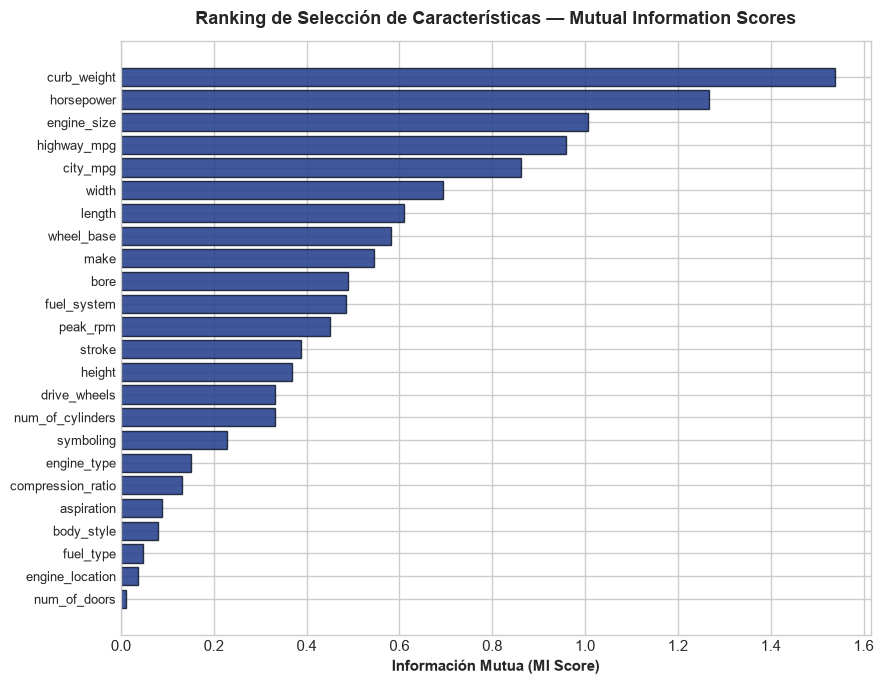

In [4]:
def plot_mi_scores(scores):
    """Genera un gráfico de barras horizontales estilizado con las puntuaciones MI."""
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    
    plt.barh(width, scores, color="#1e3a8a", alpha=0.85, edgecolor="#0f172a")
    plt.yticks(width, ticks, fontsize=9.5)
    plt.xlabel("Información Mutua (MI Score)", fontsize=11, fontweight="bold")
    plt.title("Ranking de Selección de Características — Mutual Information Scores", fontsize=13, fontweight="bold", pad=12)

plt.figure(dpi=100, figsize=(9, 7))
plot_mi_scores(mi_scores)
plt.show()


#### 7.4 Exploración Visual de Relaciones y Efectos de Interacción

La visualización de datos es el complemento indispensable de las métricas de utilidad como MI.

#### 1. Característica con Alto MI: `curb_weight` ($MI \approx 0.91$)
Como anticipaba su alto puntaje, el peso del vehículo (`curb_weight`) exhibe una relación fuertemente monótona y consistente con el precio:


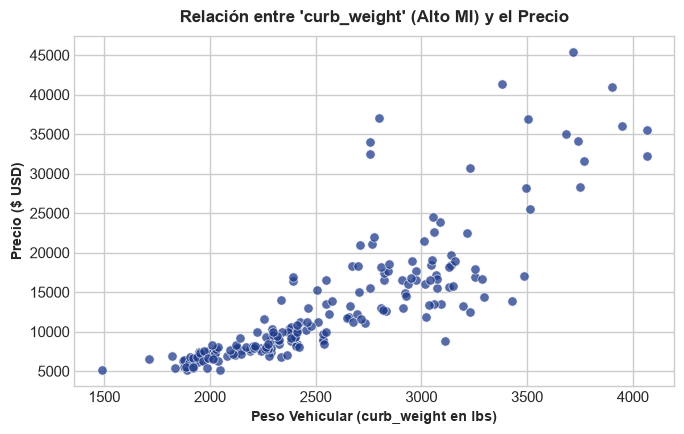

In [5]:
# Relación directa entre curb_weight y price
plt.figure(figsize=(7, 4.5), dpi=100)
sns.scatterplot(x="curb_weight", y="price", data=df, color="#1e3a8a", alpha=0.75, s=45, edgecolor="white")
plt.title("Relación entre 'curb_weight' (Alto MI) y el Precio", fontsize=12, fontweight="bold")
plt.xlabel("Peso Vehicular (curb_weight en lbs)", fontsize=10, fontweight="bold")
plt.ylabel("Precio ($ USD)", fontsize=10, fontweight="bold")
plt.show()


#### 2. Característica con Bajo MI pero Alto Efecto de Interacción: `fuel_type` ($MI \approx 0.048$)

La característica `fuel_type` (gasolina vs diésel) obtuvo una puntuación de MI muy baja ($< 0.05$). Sin embargo, al cruzarla con la potencia (`horsepower`), observamos un **efecto de interacción determinante**:


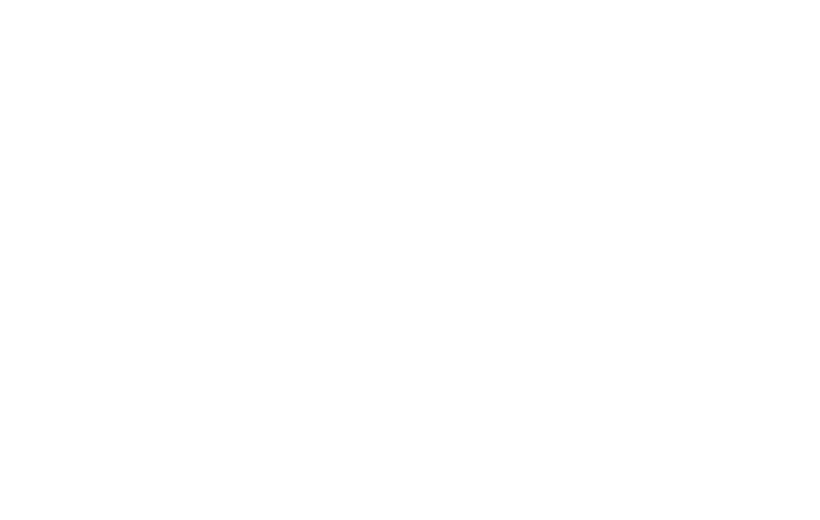

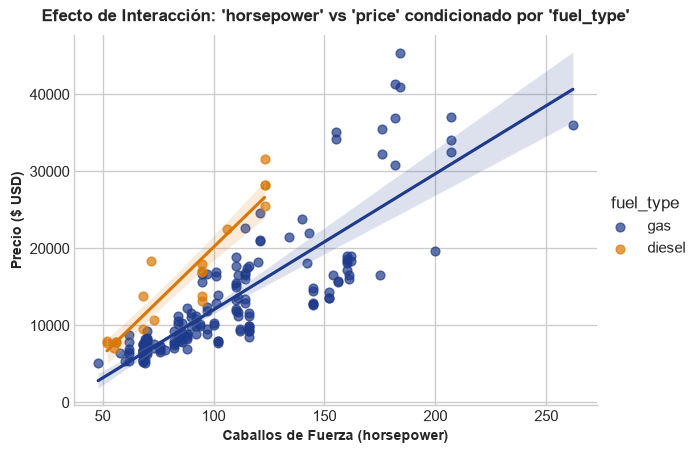

In [6]:
# Efecto de interacción: fuel_type separa dos poblaciones con distintas pendientes
plt.figure(figsize=(8, 5), dpi=100)
sns.lmplot(x="horsepower", y="price", hue="fuel_type", data=df, aspect=1.4, height=4.5,
           palette=["#1e3a8a", "#d97706"], scatter_kws={"alpha": 0.7, "s": 40})
plt.title("Efecto de Interacción: 'horsepower' vs 'price' condicionado por 'fuel_type'", fontsize=12, fontweight="bold")
plt.xlabel("Caballos de Fuerza (horsepower)", fontsize=10, fontweight="bold")
plt.ylabel("Precio ($ USD)", fontsize=10, fontweight="bold")
plt.show()


🔎 **Lección Crucial de Feature Engineering:**  
`fuel_type` separa claramente dos poblaciones con dinámicas y pendientes de precio distintas dentro de la variable `horsepower`. 
* Por sí sola (univariada), `fuel_type` no explica mucho el precio.
* Pero combinada con `horsepower` (interacción bivariada), es sumamente informativa.
* **Regla práctica:** Antes de descartar una característica con bajo MI, evalúa posibles interacciones con el conocimiento de dominio del problema.


---
##### 🛠️ Práctica 1: Comparación entre SelectKBest (Filtro Lineal) e Información Mutua

En este ejercicio compararás los resultados de un filtro lineal clásico (`f_regression` / ANOVA) frente al filtro no paramétrico de Información Mutua (`mutual_info_regression`):

1. Selecciona todas las columnas numéricas continuas de `df` (excluyendo `price`).
2. Ajusta `SelectKBest(f_regression, k='all')` y obtén las puntuaciones $F$.
3. Calcula las puntuaciones $MI$ sobre el mismo conjunto numérico.
4. Construye un DataFrame comparativo con ambas métricas normalizadas entre 0 y 1.
5. Identifica qué variables tienen baja correlación lineal pero alta Información Mutua.


In [ ]:
# =========================================================================
# TU SOLUCIÓN AQUÍ:
# =========================================================================
# 1. Seleccionar columnas numéricas
# X_numeric = ...

# 2. Aplicar SelectKBest con f_regression
# selector_f = SelectKBest(score_func=f_regression, k=5)
# ...

# 3. Comparar con el Top 5 de make_mi_scores
# ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Seleccionar variables numéricas continuas
numeric_cols = df.select_dtypes(["int64", "float64"]).columns.drop("price")
X_num = df[numeric_cols].copy()
y_target = df["price"]

# 2. SelectKBest con f_regression (Lineal)
selector_f = SelectKBest(score_func=f_regression, k=5)
selector_f.fit(X_num, y_target)

f_scores = pd.Series(selector_f.scores_, index=numeric_cols).sort_values(ascending=False)

# 3. MI Scores en variables numéricas
mi_num = make_mi_scores(X_num, y_target, discrete_features=False)

# Comparativa lado a lado
comp_df = pd.DataFrame({
    "Top 5 Lineal (f_regression)": f_scores.head(5).index,
    "F-Score": f_scores.head(5).values.round(2),
    "Top 5 No Lineal (Mutual Info)": mi_num.head(5).index,
    "MI Score": mi_num.head(5).values.round(4)
})
print("--- Comparativa Top 5 de Selección de Características ---")
display(comp_df)
```

**Conclusión pedagógica:**
* Ambos métodos identifican `curb_weight`, `engine_size` y `horsepower` como el núcleo central de variables predictivas.
* Sin embargo, `f_regression` asume relaciones estrictamente lineales, mientras que `mutual_info_regression` captura dependencias no lineales y no asume normalidad en los residuos.
</details>


---
### 8. Resumen y Conclusiones 📌

1. **La Selección de Características** reduce el número de variables descartando ruido, previniendo la maldición de la dimensionalidad y acelerando el entrenamiento sin alterar la interpretabilidad original.
2. **Métodos de Filtro (*Filter Methods*):** Son el primer paso ideal en el pipeline: ultrarrápidos y sin riesgo de sobreajuste al modelo.
3. **Información Mutua (*Mutual Information*):** Detecta cualquier tipo de relación (lineal o no lineal) y mide la reducción de incertidumbre (entropía) sobre el objetivo.
4. **Cuidado con las Interacciones:** Variables con bajo MI univariado pueden tener un efecto multiplicativo o de interacción clave (ej. `fuel_type` con `horsepower`).
5. **Prevención de Data Leakage:** Ajusta siempre cualquier método de selección de características **exclusivamente sobre el conjunto de entrenamiento (*Train Set*)**.

---

<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
